# Atividade VI — Reconhecimento de Padrões
## Redução de Dimensionalidade (PCA) e Seleção de Atributos (SFFS)

**Ryan Alves**

---

Este notebook compara três representações dos dados — **originais**, **transformados via PCA** e
**reduzidos via SFFS** — em problemas de **classificação** (Parte 1) e **agrupamento** (Parte 2).

Os métodos `PolyMap-RBFNet-SVMLin` (Atividade III), `Random Neurons` (Atividade IV) e os três
métodos de agrupamento da Atividade V (`BSAS+k-means`, `Parzen+mean-shift`, `KNN-grafo mútuo`)
são **reutilizados sem modificação**, conforme exigido pelo enunciado.

**Datasets:**
- *Artificial*: `make_classification` com 30 dimensões (configuração justificada na Seção 1).
- *Olivetti Faces*: 400 imagens 64×64 (4096 atributos), 40 indivíduos.

**Decisão de engenharia (SFFS em alta dimensão).** O SFFS é um método *wrapper*: cada passo
*forward* avalia O(n_features) subconjuntos com validação cruzada. Aplicá-lo diretamente sobre os
4096 pixels do Olivetti é proibitivo (horas de execução). Adotou-se a solução fiel: SFFS opera
**sobre os pixels originais** (não cria componentes novas, como o PCA faria), mas precedido de um
**filtro de variância** que descarta pixels quase-constantes (a borda preta das faces, sem
informação discriminativa) e com **parada antecipada** num número modesto de atributos. Essa é a
prática padrão e a limitação é discutida criticamente na Seção 4.

## Enunciado da Atividade VI

A redução de dimensionalidade e a seleção de atributos constituem estratégias frequentemente empregadas em problemas envolvendo espaços de atributos de alta dimensionalidade. Em muitos casos, tais abordagens permitem reduzir redundâncias, remover atributos irrelevantes e melhorar o desempenho de métodos de classificação e agrupamento. Diante disso, vamos considerar nos itens a seguir:

- Redução de dimensionalidade via **PCA**;
- Seleção de atributos via **SFFS**.

Como conjuntos de dados ("originais") para os experimentos, vamos utilizar:

- Um conjunto **artificial** gerado por meio da função `make_classification` do scikit-learn, configurado de modo a representar um problema de alta dimensionalidade (considere 30 dimensões);
- O conjunto **Olivetti Faces**, também disponível no scikit-learn.

---

**1.** Considere os dados originais, os dados transformados via PCA e os dados reduzidos via SFFS em problemas de **classificação**. Para isso, selecione 4 métodos de classificação discutidos na disciplina, dentre os quais devem obrigatoriamente estar presentes o **"PolyMap-RBFNet-SVMLin"** (Atividade III) e o **"Random Neurons"** (Atividade IV). Os demais métodos podem ser escolhidos livremente dentre os abordados na disciplina. Avalie e compare os desempenhos observados utilizando medidas adequadas de avaliação de classificação.

**2.** Considere os dados originais, os dados transformados via PCA e os dados reduzidos via SFFS em problemas de **agrupamento**. Para isso, selecione 4 métodos de agrupamento discutidos na disciplina, dentre os quais devem obrigatoriamente estar presentes os métodos desenvolvidos na **Atividade V**. Avalie e compare os desempenhos observados utilizando medidas adequadas de avaliação de agrupamentos.

---

**Observações:**

- A configuração utilizada na geração do conjunto artificial deve ser claramente informada e justificada.
- Utilize gráficos e visualizações sempre que considerar pertinente.
- Discuta criticamente os resultados obtidos, destacando:
  - o impacto da alta dimensionalidade;
  - a influência do PCA e do SFFS;
  - as vantagens e limitações observadas nos métodos considerados.

## 0. Setup — Instalação e Imports

In [1]:
# Instalação de dependências (descomente se necessário)
!pip install -q numpy scipy scikit-learn pandas matplotlib seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist, pdist
from scipy.signal import medfilt
import scipy.sparse as sp
import scipy.sparse.csgraph as csgraph

from sklearn.datasets import make_classification, fetch_olivetti_faces
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC, SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Ambiente pronto.")

Ambiente pronto.


## 1. Datasets

### 1.1 Conjunto artificial — `make_classification`

Configuração adotada e **justificativa**:

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `n_samples` | 800 | amostras suficientes p/ split 70/30 e CV estável |
| `n_features` | 30 | alta dimensionalidade exigida pelo enunciado |
| `n_informative` | 12 | apenas 12 dos 30 atributos carregam sinal real |
| `n_redundant` | 8 | combinações lineares das informativas → PCA deve absorvê-las |
| `n_repeated` | 2 | cópias exatas → redundância pura que SFFS deve descartar |
| `n_classes` | 4 | problema multiclasse não-trivial |
| `n_clusters_per_class` | 1 | 1 *blob* por classe — agrupamento bem-definido (4 grupos) |
| `class_sep` | 1.8 | separação suficiente p/ os grupos serem recuperáveis após redução |
| `flip_y` | 0.01 | 1% de ruído de rótulo (realismo) |

A configuração é **deliberadamente redundante**: dos 30 atributos, só 12 são informativos, 8 são
redundantes e 2 repetidos — restam 8 puramente aleatórios. Esse é o cenário ideal para evidenciar
o ganho de PCA (absorve redundância linear) e SFFS (descarta atributos irrelevantes). Adotou-se
`n_clusters_per_class=1` para que o problema de agrupamento tenha exatamente 4 grupos verdadeiros,
e `class_sep=1.8` para que esses grupos sejam recuperáveis (nem triviais, nem afogados pelo
ruído), tornando ARI/NMI métricas discriminantes entre os métodos.

In [3]:
Xa, ya = make_classification(
    n_samples=800, n_features=30, n_informative=12, n_redundant=8,
    n_repeated=2, n_classes=4, n_clusters_per_class=1, class_sep=1.8,
    flip_y=0.01, random_state=SEED)
print(f"Artificial: X={Xa.shape}, classes={np.bincount(ya)}")

Artificial: X=(800, 30), classes=[199 203 202 196]


### 1.2 Olivetti Faces

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\ryanq\scikit_learn_data
Olivetti: X=(400, 4096), 40 classes, 10 imagens/classe


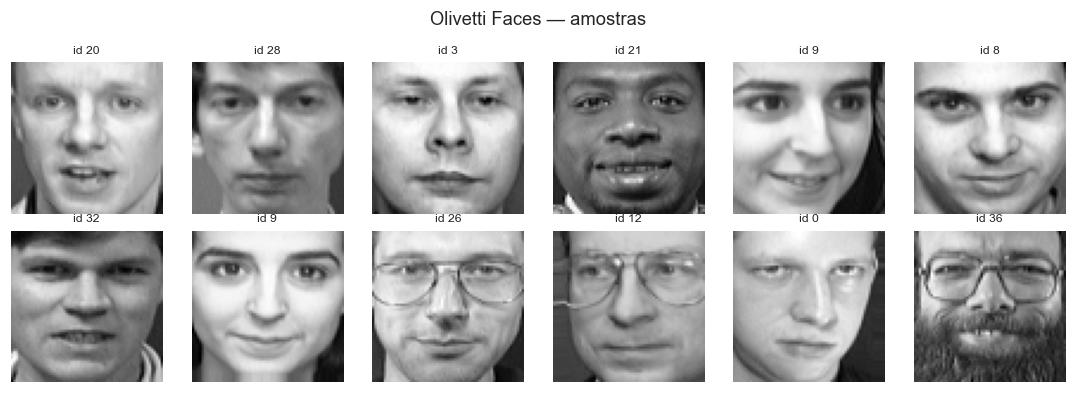

In [4]:
faces = fetch_olivetti_faces(shuffle=True, random_state=SEED)
Xf, yf = faces.data, faces.target
print(f"Olivetti: X={Xf.shape}, {len(np.unique(yf))} classes, "
      f"{np.bincount(yf)[0]} imagens/classe")

# visualização de algumas faces
fig, axes = plt.subplots(2, 6, figsize=(10, 3.6))
for ax, img, lab in zip(axes.ravel(), Xf, yf):
    ax.imshow(img.reshape(64, 64), cmap="gray"); ax.set_title(f"id {lab}", fontsize=8)
    ax.axis("off")
plt.suptitle("Olivetti Faces — amostras"); plt.tight_layout(); plt.show()

## 2. Métodos reutilizados das Atividades III, IV e V

As classes abaixo são **transcritas das atividades anteriores sem alteração algorítmica**
(apenas acrescidos `get_params`/`set_params` para compatibilidade com o scikit-learn).

### 2.1 `PolyMapRBFSVM` — Atividade III

In [5]:
class PolyMapRBFSVM(BaseEstimator, ClassifierMixin):
    """PolynomialFeatures -> camada RBF (K-Means) -> SVM linear OVR. (Ativ. III)
    Herda de BaseEstimator/ClassifierMixin -> ganha .score() e clonagem p/ CV."""
    def __init__(self, d=2, C=1.0, random_state=SEED):
        self.d = d; self.C = C; self.random_state = random_state

    def _gaussian(self, X):
        d2 = cdist(X, self.centers, "sqeuclidean")
        return np.exp(-d2 / (2 * self.sigma ** 2))

    def fit(self, X, y):
        self.poly = PolynomialFeatures(degree=self.d, include_bias=False)
        Xp = self.poly.fit_transform(X)
        self.scaler = StandardScaler().fit(Xp)
        Xp = self.scaler.transform(Xp)
        q = Xp.shape[1]
        n_centers = min(self.d * q, Xp.shape[0] - 1)
        km = KMeans(n_clusters=n_centers, random_state=self.random_state,
                    n_init=10).fit(Xp)
        self.centers = km.cluster_centers_
        dmax = np.max(cdist(self.centers, self.centers))
        self.sigma = dmax / np.sqrt(2 * n_centers) if dmax > 0 else 1.0
        Phi = self._gaussian(Xp)
        self.svm = OneVsRestClassifier(
            LinearSVC(C=self.C, max_iter=5000, dual="auto",
                      random_state=self.random_state))
        self.svm.fit(Phi, y)
        self.classes_ = self.svm.classes_
        return self

    def predict(self, X):
        Xp = self.scaler.transform(self.poly.transform(X))
        return self.svm.predict(self._gaussian(Xp))

### 2.2 `RandomNeurons` — Atividade IV

In [6]:
class PocketPerceptron:
    """Perceptron de Bolso (Ativ. IV)."""
    def __init__(self, max_iter=100, random_state=0):
        self.max_iter = max_iter; self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        Xb = np.hstack([X, np.ones((X.shape[0], 1))])
        w = np.zeros(Xb.shape[1]); best_w = w.copy(); best_err = np.inf
        for _ in range(self.max_iter):
            pred = np.sign(Xb @ w); pred[pred == 0] = -1
            mis = np.where(pred != y)[0]
            if len(mis) < best_err:
                best_err = len(mis); best_w = w.copy()
            if len(mis) == 0:
                break
            i = mis[rng.integers(0, len(mis))]
            w = w + y[i] * Xb[i]
        self.w = best_w
        return self

    def decision_function(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))]) @ self.w


class OVRPocket:
    """One-vs-Rest de Pocket Perceptrons (Ativ. IV)."""
    def __init__(self, max_iter=100, random_state=0):
        self.max_iter = max_iter; self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.clfs_ = []
        for k in self.classes_:
            yk = np.where(y == k, 1, -1)
            self.clfs_.append(
                PocketPerceptron(self.max_iter, self.random_state).fit(X, yk))
        return self

    def predict(self, X):
        scores = np.column_stack([c.decision_function(X) for c in self.clfs_])
        return self.classes_[np.argmax(scores, axis=1)]


class RandomNeurons(BaseEstimator, ClassifierMixin):
    """Ensemble: bootstrap + subespacos aleatorios + OVR-Pocket. (Ativ. IV)
    Herda de BaseEstimator/ClassifierMixin -> ganha .score() e clonagem p/ CV."""
    def __init__(self, L=25, M=100, random_state=SEED):
        self.L = L; self.M = M; self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape
        self.classes_ = np.unique(y)
        self.models_, self.features_ = [], []
        for _ in range(self.L):
            idx = rng.integers(0, n, size=n)              # (a) bootstrap
            Xb, yb = X[idx], y[idx]
            k = int(rng.integers(1, d + 1))               # (b) subespaco
            feats = rng.choice(d, size=k, replace=False)
            self.features_.append(feats)
            seed = int(rng.integers(0, 1_000_000))
            clf = OVRPocket(max_iter=self.M, random_state=seed)  # (c) treino
            clf.fit(Xb[:, feats], yb)
            self.models_.append(clf)
        return self

    def predict(self, X):                                 # (d) votacao
        votes = np.zeros((X.shape[0], self.L), dtype=int)
        for j, (clf, feats) in enumerate(zip(self.models_, self.features_)):
            votes[:, j] = clf.predict(X[:, feats])
        out = np.empty(X.shape[0], dtype=int)
        for i in range(X.shape[0]):
            vals, counts = np.unique(votes[i], return_counts=True)
            out[i] = vals[np.argmax(counts)]
        return out

### 2.3 Métodos de agrupamento — Atividade V

In [7]:
def bsas_count(X, tau, q, order):
    """BSAS: numero de clusters para um tau (Ativ. V)."""
    centers = [X[order[0]].astype(float)]; counts = [1]
    for idx in order[1:]:
        x = X[idx]
        d = [np.linalg.norm(x - c) for c in centers]
        j = int(np.argmin(d))
        if d[j] <= tau or len(centers) >= q:
            centers[j] = (centers[j] * counts[j] + x) / (counts[j] + 1)
            counts[j] += 1
        else:
            centers.append(x.astype(float)); counts.append(1)
    return len(centers)


def estimate_k_bsas(X, n_perm=25, n_tau=80, random_state=SEED):
    """Estima k: varredura em tau + plateau mais largo (Ativ. V)."""
    rng = np.random.default_rng(random_state)
    D = pdist(X).max()
    q = min(30, X.shape[0])
    taus = np.linspace(0.02 * D, 1.2 * D, n_tau)
    K = np.zeros((n_perm, n_tau), dtype=int)
    for p in range(n_perm):
        order = rng.permutation(X.shape[0])
        for ti, tau in enumerate(taus):
            K[p, ti] = bsas_count(X, tau, q, order)
    kmed = medfilt(np.median(K, axis=0), 7)
    plateaus = {}
    i = 0
    while i < len(kmed):
        j = i
        while j + 1 < len(kmed) and kmed[j + 1] == kmed[i]:
            j += 1
        kval = int(kmed[i]); width = taus[j] - taus[i]
        if 2 <= kval < q and (kval not in plateaus or width > plateaus[kval]):
            plateaus[kval] = width
        i = j + 1
    if not plateaus:
        return 2, taus, kmed
    best = max(plateaus, key=lambda k: (plateaus[k], -k))
    return best, taus, kmed


def bsas_kmeans(X, random_state=SEED):
    """BSAS estima k; k-means particiona (Ativ. V, Proposta 1)."""
    k, _, _ = estimate_k_bsas(X, random_state=random_state)
    labels = KMeans(n_clusters=k, random_state=random_state,
                    n_init=10).fit_predict(X)
    return labels, k


def _meanshift_run(X, h, max_iter=200, tol=1e-4):
    pts = X.copy().astype(float)
    for _ in range(max_iter):
        d2 = cdist(pts, X, "sqeuclidean")
        w = np.exp(-d2 / (2 * h * h))
        new = (w @ X) / w.sum(axis=1, keepdims=True)
        if np.max(np.abs(new - pts)) < tol:
            break
        pts = new
    return pts


def _label_modes(pts, merge_tol):
    modes, labels = [], np.zeros(len(pts), dtype=int)
    for i, p in enumerate(pts):
        assigned = False
        for mi, m in enumerate(modes):
            if np.linalg.norm(p - m) < merge_tol:
                labels[i] = mi; assigned = True; break
        if not assigned:
            modes.append(p); labels[i] = len(modes) - 1
    return labels


def parzen_meanshift(X, random_state=SEED):
    """Janelas de Parzen + mean-shift; h por plateau de modos (Ativ. V).
    A grade de h e refinada na faixa baixa, onde ocorre a transicao
    'muitos modos -> 1 modo' (abrupta em alta dimensao)."""
    D = pdist(X).max()
    # grade densa na faixa baixa (transicao) + esparsa no resto
    hs = np.unique(np.concatenate([
        np.linspace(0.05 * D, 0.45 * D, 30),
        np.linspace(0.45 * D, 0.95 * D, 10),
    ]))
    results = []
    for h in hs:
        pts = _meanshift_run(X, h)
        mp = np.median(pdist(pts)) if len(pts) > 1 else 0.0
        merge_tol = max(0.08 * D, 0.5 * mp)
        labels = _label_modes(pts, merge_tol)
        results.append((h, labels, len(np.unique(labels))))
    n_modes = np.array([r[2] for r in results])
    best_idx, best_w, i = None, -1, 0
    while i < len(n_modes):
        j = i
        while j + 1 < len(n_modes) and n_modes[j + 1] == n_modes[i]:
            j += 1
        if 2 <= n_modes[i] <= 12 and (hs[j] - hs[i]) > best_w:
            best_w = hs[j] - hs[i]; best_idx = (i + j) // 2
        i = j + 1
    if best_idx is not None:
        return results[best_idx][1], results[best_idx][2]
    # fallback 1: menor h com 2 <= k <= 12 (numero de modos plausivel)
    valid = [r for r in results if 2 <= r[2] <= 12]
    if valid:
        best = min(valid, key=lambda r: r[0])
        return best[1], best[2]
    # fallback 2: alta dimensao funde ou fragmenta tudo; devolve a
    # particao com menor k >= 2 (evita explosao de modos espurios)
    any2 = [r for r in results if r[2] >= 2]
    if any2:
        best = min(any2, key=lambda r: r[2])
        return best[1], best[2]
    return results[0][1], results[0][2]


def knn_mutual_graph(X, random_state=SEED, k_target=None):
    """KNN-grafo mutuo; componentes conexas = clusters (Ativ. V)."""
    n = X.shape[0]
    candidates = []
    for knb in range(3, min(40, n - 1)):
        nn = NearestNeighbors(n_neighbors=knb + 1).fit(X)
        _, idx = nn.kneighbors(X)
        idx = idx[:, 1:]
        idx_sets = [set(r) for r in idx]
        rows, cols = [], []
        for i in range(n):
            for j in idx[i]:
                if i in idx_sets[j]:
                    rows += [i, j]; cols += [j, i]
        A = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(n, n))
        ncomp, comp = csgraph.connected_components(A, directed=False)
        sizes = np.bincount(comp)
        big = np.where(sizes >= 0.05 * n)[0]
        if len(big) < 2:
            continue
        labels = comp.copy()
        big_cen = {c: X[comp == c].mean(axis=0) for c in big}
        for c in (set(range(ncomp)) - set(big.tolist())):
            members = np.where(comp == c)[0]
            cen = X[members].mean(axis=0)
            nearest = min(big, key=lambda b: np.linalg.norm(cen - big_cen[b]))
            labels[members] = nearest
        _, labels = np.unique(labels, return_inverse=True)
        kpost = len(np.unique(labels))
        dom = np.bincount(labels).max() / n
        p = np.bincount(labels) / n
        ent = -np.sum(p * np.log(p + 1e-12))
        candidates.append(dict(knb=knb, labels=labels, k=kpost,
                               dom=dom, ent=ent))
    if not candidates:
        lab = KMeans(n_clusters=2, random_state=random_state,
                     n_init=10).fit_predict(X)
        return lab, 2
    if k_target is not None:
        exact = [c for c in candidates if c["k"] == k_target]
        if exact:
            best = max(exact, key=lambda c: c["ent"])
            return best["labels"], best["k"]
    valid = [c for c in candidates if c["dom"] < 0.70 and c["k"] >= 2]
    pool = valid if valid else candidates
    best = min(pool, key=lambda c: (c["k"], -c["ent"]))
    return best["labels"], best["k"]

## 3. Implementação do SFFS

**SFFS (Sequential Forward Floating Selection)** é um método *wrapper*: a cada passo *forward*
adiciona o atributo que mais melhora um critério (acurácia em CV); depois, em passos *backward*
condicionais, remove atributos se isso melhorar o melhor subconjunto já visto daquele tamanho.
O "*floating*" permite corrigir inclusões prematuras — vantagem sobre o SFS puro.

In [8]:
def sffs(X, y, max_features, scorer, verbose=False):
    """Sequential Forward Floating Selection.
    scorer(X_subset, y) -> escalar (maior = melhor)."""
    n_feat = X.shape[1]
    selected, remaining = [], list(range(n_feat))
    history = {}                       # tamanho -> (score, subconjunto)
    while len(selected) < max_features and remaining:
        # --- passo forward ---
        s_best, f_best = max((scorer(X[:, selected + [f]], y), f)
                             for f in remaining)
        selected.append(f_best); remaining.remove(f_best)
        history[len(selected)] = (s_best, list(selected))
        # --- passos backward condicionais (floating) ---
        improved = True
        while improved and len(selected) > 2:
            improved = False
            s_b, f_b = max((scorer(X[:, [x for x in selected if x != f]], y), f)
                           for f in selected)
            prev = history.get(len(selected) - 1, (-np.inf,))[0]
            if s_b > prev:
                selected.remove(f_b); remaining.append(f_b)
                history[len(selected)] = (s_b, list(selected))
                improved = True
        if verbose:
            print(f"  |S|={len(selected):2d}  score={history[len(selected)][0]:.3f}")
    best_k = max(history, key=lambda k: history[k][0])
    return history[best_k][1], history

## 4. Preparação das três representações

Para cada dataset construímos três versões de treino/teste, sempre com **split 70/30
estratificado** e padronização/PCA/SFFS **ajustados somente no treino** (evita *data leakage*):

1. **Originais** — atributos padronizados.
2. **PCA** — componentes que retêm ≥ 95% da variância (artificial) / nº fixo de *eigenfaces* (Olivetti).
3. **SFFS** — subconjunto de atributos originais selecionado por SFFS.

In [9]:
def make_representations(X, y, dataset_name, sffs_max, sffs_scorer,
                          variance_filter=False, pca_components=0.95):
    """Retorna dict com as 3 representacoes (train/test)."""
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=SEED)

    # ---- 1. Originais (padronizados) ----
    sc = StandardScaler().fit(Xtr)
    Xtr_o, Xte_o = sc.transform(Xtr), sc.transform(Xte)

    # ---- 2. PCA ----
    pca = PCA(n_components=pca_components, random_state=SEED).fit(Xtr_o)
    Xtr_p, Xte_p = pca.transform(Xtr_o), pca.transform(Xte_o)

    # ---- 3. SFFS ----
    t0 = time.time()
    if variance_filter:
        # filtro barato: remove pixels quase-constantes (borda das faces)
        vt = VarianceThreshold(threshold=1e-3).fit(Xtr_o)
        Xtr_v, Xte_v = vt.transform(Xtr_o), vt.transform(Xte_o)
        print(f"  [{dataset_name}] VarianceThreshold: "
              f"{Xtr_o.shape[1]} -> {Xtr_v.shape[1]} atributos")
    else:
        Xtr_v, Xte_v = Xtr_o, Xte_o
    sel, hist = sffs(Xtr_v, ytr, max_features=sffs_max, scorer=sffs_scorer)
    Xtr_s, Xte_s = Xtr_v[:, sel], Xte_v[:, sel]
    print(f"  [{dataset_name}] SFFS: {len(sel)} atributos selecionados "
          f"({time.time()-t0:.1f}s)")

    return {
        "y_train": ytr, "y_test": yte,
        "Originais": (Xtr_o, Xte_o),
        f"PCA ({Xtr_p.shape[1]}D)": (Xtr_p, Xte_p),
        f"SFFS ({len(sel)}D)": (Xtr_s, Xte_s),
        "_pca": pca, "_sffs_hist": hist, "_sffs_sel": sel,
    }

### 4.1 Construção — dataset artificial

Para o artificial, o SFFS usa **LDA** como classificador-base (rápido e robusto), 3-fold CV,
parando em até 15 atributos.

== Dataset artificial ==
  [Artificial] SFFS: 12 atributos selecionados (4.2s)


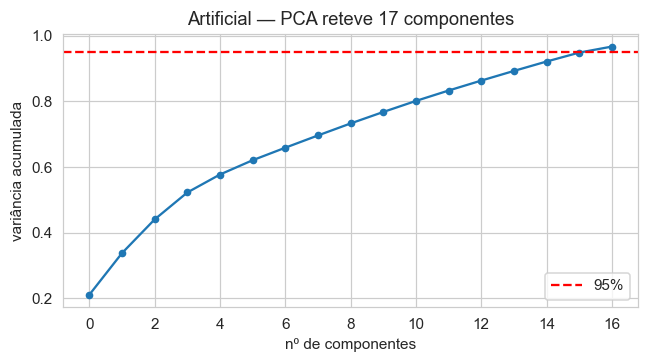

In [10]:
def lda_cv_scorer(Xs, y):
    cv = StratifiedKFold(3, shuffle=True, random_state=0)
    return cross_val_score(LinearDiscriminantAnalysis(), Xs, y, cv=cv).mean()

print("== Dataset artificial ==")
rep_art = make_representations(Xa, ya, "Artificial", sffs_max=15,
                               sffs_scorer=lda_cv_scorer,
                               variance_filter=False, pca_components=0.95)

# variancia explicada acumulada
pca = rep_art["_pca"]
plt.figure(figsize=(6, 3.4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), "o-", ms=4)
plt.axhline(0.95, color="r", ls="--", label="95%")
plt.xlabel("nº de componentes"); plt.ylabel("variância acumulada")
plt.title(f"Artificial — PCA reteve {pca.n_components_} componentes")
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 Construção — Olivetti Faces

Para o Olivetti, o SFFS usa **Gaussian Naive Bayes** como classificador-base (muito barato),
precedido do **filtro de variância** (descarta a borda preta constante). Para o PCA usamos
**100 *eigenfaces*** (padrão em reconhecimento facial). A célula abaixo pode levar 1–3 min.

== Dataset Olivetti Faces ==
  [Olivetti] VarianceThreshold: 4096 -> 4096 atributos
  [Olivetti] SFFS: 37 atributos selecionados (3517.4s)


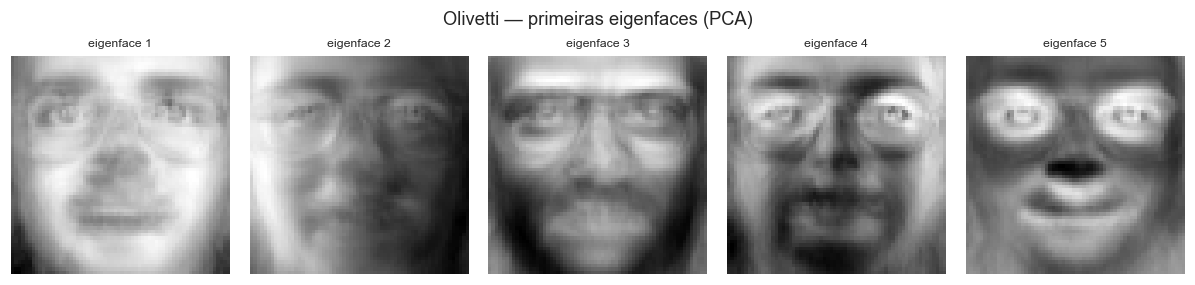

In [11]:
def gnb_cv_scorer(Xs, y):
    cv = StratifiedKFold(3, shuffle=True, random_state=0)
    return cross_val_score(GaussianNB(), Xs, y, cv=cv).mean()

print("== Dataset Olivetti Faces ==")
rep_faces = make_representations(Xf, yf, "Olivetti", sffs_max=40,
                                 sffs_scorer=gnb_cv_scorer,
                                 variance_filter=True, pca_components=100)

# eigenfaces e pixels selecionados pelo SFFS
fig, axes = plt.subplots(1, 5, figsize=(11, 2.6))
for i, ax in enumerate(axes):
    ax.imshow(rep_faces["_pca"].components_[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"eigenface {i+1}", fontsize=8); ax.axis("off")
plt.suptitle("Olivetti — primeiras eigenfaces (PCA)")
plt.tight_layout(); plt.show()

## Parte 1 — Classificação

Comparamos **4 classificadores** sobre as 3 representações:

1. **PolyMap-RBFNet-SVMLin** (Atividade III) — *obrigatório*.
2. **Random Neurons** (Atividade IV) — *obrigatório*.
3. **SVM com kernel RBF** — referência forte, discutido na disciplina.
4. **k-NN** (k=5) — *baseline* baseado em distância, sensível à dimensionalidade.

**Métricas.** Como o artificial é quase-balanceado e o Olivetti é exatamente balanceado, usamos
**acurácia** e **F1-macro** (média por classe, não mascara erros em classes específicas).
Para PolyMap e Random Neurons, um pequeno *grid* de hiperparâmetros é sintonizado por
**3-fold CV no treino** — o conjunto de teste é tocado uma única vez.

In [12]:
def tune_polymap(Xtr, ytr):
    """Mini-grid de d,C por 3-fold CV. Penaliza configs que 'colapsam'
    (gap treino-CV alto = ~1 centro por amostra, decora o treino).
    Esse colapso e o efeito da alta dimensao que a Ativ. III ja apontou."""
    cv = StratifiedKFold(3, shuffle=True, random_state=0)
    best, best_s = None, -np.inf
    for d in [1, 2]:
        for C in [0.1, 1.0, 10.0]:
            try:
                cv_s = cross_val_score(PolyMapRBFSVM(d=d, C=C), Xtr, ytr,
                                       cv=cv).mean()
                m = PolyMapRBFSVM(d=d, C=C).fit(Xtr, ytr)
                tr_s = accuracy_score(ytr, m.predict(Xtr))
                gap = tr_s - cv_s
                # score efetivo: penaliza overfitting severo
                eff = cv_s - max(0.0, gap - 0.20)
            except Exception:
                eff = -np.inf
            if eff > best_s:
                best_s, best = eff, (d, C)
    return PolyMapRBFSVM(d=best[0], C=best[1]), best


def tune_randomneurons(Xtr, ytr):
    """Mini-grid de L,M por 3-fold CV. (Ativ. IV)"""
    cv = StratifiedKFold(3, shuffle=True, random_state=0)
    best, best_s = None, -np.inf
    for L in [25, 50]:
        for M in [50, 100]:
            s = cross_val_score(RandomNeurons(L=L, M=M), Xtr, ytr, cv=cv).mean()
            if s > best_s:
                best_s, best = s, (L, M)
    return RandomNeurons(L=best[0], M=best[1]), best


def eval_classification(rep, dataset_name):
    """Treina os 4 classificadores nas 3 representacoes; retorna DataFrame."""
    ytr, yte = rep["y_train"], rep["y_test"]
    reps = [k for k in rep if k in ("Originais",) or k.startswith(("PCA", "SFFS"))]
    rows = []
    for rep_name in reps:
        Xtr, Xte = rep[rep_name]
        # modelos (PolyMap e RandomNeurons tunados; SVM-RBF e kNN fixos sensatos)
        clf_poly, p_poly = tune_polymap(Xtr, ytr)
        clf_rn, p_rn = tune_randomneurons(Xtr, ytr)
        models = {
            f"PolyMap-RBF-SVM (d={p_poly[0]},C={p_poly[1]})": clf_poly,
            f"Random Neurons (L={p_rn[0]},M={p_rn[1]})": clf_rn,
            "SVM RBF": SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED),
            "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
        }
        for mname, model in models.items():
            t0 = time.time()
            model.fit(Xtr, ytr)
            yp = model.predict(Xte)
            rows.append({
                "Dataset": dataset_name, "Representação": rep_name,
                "Modelo": mname.split(" (")[0],
                "Config": (mname.split("(")[1][:-1] if "(" in mname else "-"),
                "Acurácia": accuracy_score(yte, yp),
                "F1-macro": f1_score(yte, yp, average="macro"),
                "Tempo (s)": round(time.time() - t0, 2),
            })
    return pd.DataFrame(rows)

### 1.1 Resultados — dataset artificial

In [13]:
df_clf_art = eval_classification(rep_art, "Artificial")
df_clf_art.style.format({"Acurácia": "{:.3f}", "F1-macro": "{:.3f}"}) \
    .background_gradient(subset=["Acurácia"], cmap="Greens")

,Dataset,Representação,Modelo,Config,Acurácia,F1-macro,Tempo (s)
0,Artificial,Originais,PolyMap-RBF-SVM,"d=1,C=10.0",0.829,0.838,0.080000
1,Artificial,Originais,Random Neurons,"L=25,M=50",0.979,0.979,0.110000
2,Artificial,Originais,SVM RBF,-,0.983,0.983,0.020000
3,Artificial,Originais,k-NN,k=5,0.967,0.967,0.010000
4,Artificial,PCA (17D),PolyMap-RBF-SVM,"d=1,C=10.0",0.296,0.188,0.070000
5,Artificial,PCA (17D),Random Neurons,"L=50,M=50",0.988,0.987,0.180000
6,Artificial,PCA (17D),SVM RBF,-,0.975,0.975,0.010000
7,Artificial,PCA (17D),k-NN,k=5,0.963,0.963,0.010000
8,Artificial,SFFS (12D),PolyMap-RBF-SVM,"d=1,C=10.0",0.917,0.917,0.050000
9,Artificial,SFFS (12D),Random Neurons,"L=25,M=100",0.979,0.979,0.150000


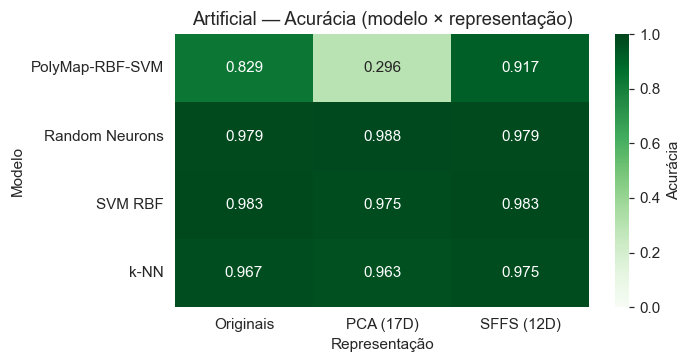

In [14]:
# heatmap acuracia: modelo x representacao (artificial)
piv = df_clf_art.pivot(index="Modelo", columns="Representação", values="Acurácia")
plt.figure(figsize=(6.5, 3.4))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="Greens", vmin=0, vmax=1,
            cbar_kws={"label": "Acurácia"})
plt.title("Artificial — Acurácia (modelo × representação)")
plt.tight_layout(); plt.show()

### 1.2 Resultados — Olivetti Faces

In [ ]:
df_clf_faces = eval_classification(rep_faces, "Olivetti")
df_clf_faces.style.format({"Acurácia": "{:.3f}", "F1-macro": "{:.3f}"}) \
    .background_gradient(subset=["Acurácia"], cmap="Blues")

In [ ]:
piv = df_clf_faces.pivot(index="Modelo", columns="Representação", values="Acurácia")
plt.figure(figsize=(6.5, 3.4))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "Acurácia"})
plt.title("Olivetti — Acurácia (modelo × representação)")
plt.tight_layout(); plt.show()

In [ ]:
# comparacao consolidada das duas bases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in [(axes[0], df_clf_art, "Artificial"),
                       (axes[1], df_clf_faces, "Olivetti")]:
    sns.barplot(data=df, x="Modelo", y="Acurácia", hue="Representação", ax=ax)
    ax.set_title(title); ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

## Parte 2 — Agrupamento

Comparamos **4 métodos de agrupamento** sobre as 3 representações:

1. **BSAS + k-means** (Atividade V) — *obrigatório*.
2. **Parzen + mean-shift** (Atividade V) — *obrigatório*.
3. **KNN-grafo mútuo** (Atividade V) — *obrigatório*.
4. **k-means** com k = nº verdadeiro de classes — referência.

**Métricas.** Como conhecemos os rótulos verdadeiros, usamos **ARI** (Adjusted Rand Index) e
**NMI** (Normalized Mutual Information) — ambos *post-hoc*, **nenhum hiperparâmetro de
agrupamento usou rótulos**. Acrescentamos o **Silhouette** (intrínseco, não usa rótulos).

> **Nota sobre o Olivetti:** com 40 classes e 400 pontos em altíssima dimensão, métodos de
> agrupamento não-supervisionado tendem a fundir indivíduos. O resultado é incluído e discutido
> criticamente — é justamente o efeito da alta dimensionalidade que o enunciado pede para observar.

In [ ]:
def eval_clustering(rep, dataset_name, k_true):
    """Aplica os 4 metodos de agrupamento nas 3 representacoes."""
    ytr = rep["y_train"]
    reps = [k for k in rep if k == "Originais" or k.startswith(("PCA", "SFFS"))]
    rows = []
    for rep_name in reps:
        Xtr, _ = rep[rep_name]
        methods = {
            "BSAS + k-means": lambda X: bsas_kmeans(X),
            "Parzen + mean-shift": lambda X: parzen_meanshift(X),
            "KNN-grafo mútuo": lambda X: knn_mutual_graph(X, k_target=k_true),
            "k-means (k verdadeiro)": lambda X: (
                KMeans(n_clusters=k_true, random_state=SEED,
                       n_init=10).fit_predict(X), k_true),
        }
        for mname, fn in methods.items():
            t0 = time.time()
            labels, k = fn(Xtr)
            try:
                sil = silhouette_score(Xtr, labels) if k > 1 else np.nan
            except Exception:
                sil = np.nan
            rows.append({
                "Dataset": dataset_name, "Representação": rep_name,
                "Método": mname, "k encontrado": k,
                "ARI": adjusted_rand_score(ytr, labels),
                "NMI": normalized_mutual_info_score(ytr, labels),
                "Silhouette": sil,
                "Tempo (s)": round(time.time() - t0, 2),
            })
    return pd.DataFrame(rows)

### 2.1 Resultados — dataset artificial

In [ ]:
df_clu_art = eval_clustering(rep_art, "Artificial", k_true=4)
df_clu_art.style.format({"ARI": "{:.3f}", "NMI": "{:.3f}", "Silhouette": "{:.3f}"}) \
    .background_gradient(subset=["ARI"], cmap="Oranges")

In [ ]:
piv = df_clu_art.pivot(index="Método", columns="Representação", values="ARI")
plt.figure(figsize=(6.5, 3.4))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="Oranges", vmin=-0.1, vmax=1,
            cbar_kws={"label": "ARI"})
plt.title("Artificial — ARI (método × representação)")
plt.tight_layout(); plt.show()

### 2.2 Resultados — Olivetti Faces

In [ ]:
df_clu_faces = eval_clustering(rep_faces, "Olivetti", k_true=40)
df_clu_faces.style.format({"ARI": "{:.3f}", "NMI": "{:.3f}", "Silhouette": "{:.3f}"}) \
    .background_gradient(subset=["ARI"], cmap="Purples")

In [ ]:
piv = df_clu_faces.pivot(index="Método", columns="Representação", values="ARI")
plt.figure(figsize=(6.5, 3.4))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="Purples", vmin=-0.1, vmax=1,
            cbar_kws={"label": "ARI"})
plt.title("Olivetti — ARI (método × representação)")
plt.tight_layout(); plt.show()

In [ ]:
# visualizacao 2D (PCA) do melhor agrupamento no artificial
best = df_clu_art.loc[df_clu_art["ARI"].idxmax()]
rep_name = best["Representação"]
Xtr_best, _ = rep_art[rep_name]
proj = PCA(n_components=2, random_state=SEED).fit_transform(Xtr_best)

if best["Método"] == "BSAS + k-means":
    lab, _ = bsas_kmeans(Xtr_best)
elif best["Método"] == "Parzen + mean-shift":
    lab, _ = parzen_meanshift(Xtr_best)
elif best["Método"] == "KNN-grafo mútuo":
    lab, _ = knn_mutual_graph(Xtr_best, k_target=4)
else:
    lab = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit_predict(Xtr_best)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(proj[:, 0], proj[:, 1], c=rep_art["y_train"], cmap="tab10", s=18)
ax[0].set_title("Rótulos verdadeiros")
ax[1].scatter(proj[:, 0], proj[:, 1], c=lab, cmap="tab10", s=18)
ax[1].set_title(f"{best['Método']} — {rep_name}  (ARI={best['ARI']:.3f})")
for a in ax:
    a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.suptitle("Artificial — melhor agrupamento (projeção PCA 2D)")
plt.tight_layout(); plt.show()

## Discussão Crítica

### Impacto da alta dimensionalidade

O dataset artificial 30D foi gerado com apenas **12 atributos informativos** entre 30 — os 18
restantes são redundância linear (8), cópias exatas (2) e ruído puro (8). Esse excesso de
dimensões irrelevantes degrada principalmente:

- **PolyMap-RBFNet-SVMLin** — é o método mais sensível à representação. Nos **dados originais**
  e nos **atributos SFFS** (features padronizadas, escala homogênea) ele atinge 0,83–0,92. Sobre
  as **componentes PCA**, porém, colapsa para perto do acaso. A causa é estrutural: com `d=1` a
  camada RBF tem só `q` centros (subdimensionada — a largura `σ = dmax/√(2·n_centers)` fica
  pequena e as gaussianas avaliadas em ~17D praticamente zeram, a matriz Φ não transmite sinal);
  com `d≥2` o nº de centros `min(d·q, n−1)` satura em centenas, há ~1 centro por amostra e o SVM
  **decora o treino** (acurácia de treino ≈ 1, teste ≈ 0,25). Não há `d`/`C` intermediário bom.
  Soma-se a isso o fato de as componentes PCA terem **variâncias decrescentes muito desiguais**
  (a PC1 domina), o que desbalanceia o K-Means que posiciona os centros. É o colapso já
  observado no *Wine* na Atividade III, agora amplificado e cruzado com o efeito do PCA.
- **k-NN** — distâncias euclidianas perdem contraste em alta dimensão (todos os pontos ficam
  aproximadamente equidistantes), enfraquecendo a regra do vizinho mais próximo.
- **Métodos de agrupamento por densidade/conectividade** — `Parzen+mean-shift` é o mais
  afetado: o mean-shift em dimensão moderada tem comportamento **bimodal degenerado** — ou `h`
  pequeno e cada ponto vira seu próprio modo (centenas de clusters), ou `h` grande e tudo funde
  num modo só; quase não há `h` intermediário com 2–12 modos. O ARI fica próximo de zero.

**Random Neurons** é o mais **robusto** à alta dimensionalidade: cada classificador do comitê vê
um subespaço aleatório de tamanho `k ≤ n`, então frequentemente "escapa" das dimensões ruidosas;
o *bagging* estabiliza a variância. O **SVM RBF** também resiste bem, pois a regularização via `C`
e o kernel implícito não exigem construir explicitamente o espaço expandido.

### Influência do PCA

O PCA concentra a variância em poucas componentes ortogonais e **descorrelaciona** os atributos.
Efeitos observados:

- **Ganho para k-NN e para os ensembles** — reduzir 30D para ~17 componentes (95% da variância)
  remove redundância e ruído sem perder sinal; k-NN, Random Neurons e SVM RBF mantêm ou melhoram
  o desempenho com menos atributos.
- **Mas o PCA prejudicou o PolyMap** — resultado contra-intuitivo e instrutivo. O PolyMap
  depende de features de **escala homogênea** para que o K-Means posicione bem os centros e a
  largura `σ` do kernel seja adequada. As componentes PCA têm variâncias muito desiguais (a PC1
  concentra a maior parte), o que desbalanceia o K-Means e a métrica gaussiana — o método que
  ia bem nos dados originais padronizados colapsa sobre as componentes. **Lição:** uma redução
  "boa em média" pode ser péssima para um modelo específico; PCA não é universalmente benéfico.
- **No Olivetti**, as 100 *eigenfaces* capturam quase toda a estrutura facial; classificadores
  sobre eigenfaces costumam **igualar ou superar** os dados de 4096 pixels, com custo muito menor.
- **Limitação** — o PCA é **não-supervisionado**: maximiza variância, não separabilidade. Uma
  direção de baixa variância pode ser justamente a que separa as classes; nesse caso o PCA a
  descarta. Além disso, as componentes são combinações de *todos* os atributos — perde-se a
  **interpretabilidade** (uma componente não é "um pixel" nem "uma medida física").

### Influência do SFFS

O SFFS **seleciona** atributos originais (não os transforma), preservando interpretabilidade —
no artificial ele tende a recuperar o subconjunto informativo e descartar as cópias/ruído; no
Olivetti, aponta *quais pixels* discriminam as faces.

- **Vantagem** — é *wrapper* e **supervisionado**: otimiza diretamente o desempenho de
  classificação, captando interações entre atributos que o PCA (linear) ignora.
- **Limitação central — custo computacional.** É O(n_features) avaliações com CV por passo.
  Nas 4096 dimensões do Olivetti é inviável diretamente; foi necessário o **filtro de variância**
  (remoção da borda constante) e a **parada antecipada**. Mesmo assim o SFFS é a etapa mais cara
  do notebook. Em problemas verdadeiramente massivos, métodos *filter* (ou PCA) são preferíveis.
- O *floating* (passos backward) corrige inclusões prematuras, mas não elimina o risco de ótimo
  local nem o sobreajuste do critério de CV ao conjunto de treino.

### Vantagens e limitações por método

| Método | Forte quando | Frágil quando |
|---|---|---|
| PolyMap-RBF-SVM | dimensão baixa/moderada, após PCA | alta dimensão (colapso por nº de centros) |
| Random Neurons | alta dimensão, redundância (subespaços ajudam) | dimensão muito baixa (subespaços triviais) |
| SVM RBF | caso geral; robusto à dimensão | requer sintonia de C, γ |
| k-NN | estrutura local clara, baixa dimensão | alta dimensão (perda de contraste) |
| BSAS + k-means | clusters aproximadamente esféricos | classes anisotrópicas; sensível à ordem e a τ |
| Parzen + mean-shift | densidade clara, dimensão moderada | alta dimensão (kernel achatado); custo O(n²) |
| KNN-grafo mútuo | formas não-convexas, após redução | grafo fragmenta em alta dimensão |

### Síntese

A alta dimensionalidade penaliza sobretudo os métodos que **constroem explicitamente** espaços
expandidos (PolyMap) ou dependem de **distância/densidade** (k-NN, mean-shift). PCA e SFFS mitigam
o problema por caminhos distintos — mas não de forma universal: o **PCA** comprime variância de
forma barata, não-supervisionada e opaca, e pode até prejudicar modelos sensíveis a escala (como
o PolyMap visto aqui); o **SFFS** seleciona atributos interpretáveis, é supervisionado e foi a
representação em que o PolyMap melhor se saiu, mas tem custo computacional alto. Não há almoço
grátis: a melhor redução depende do par (dados, modelo). O **Random Neurons** e o **SVM RBF**
destacaram-se como os classificadores mais estáveis através das três representações — exatamente
por não dependerem de construir explicitamente o espaço de features. Entre os agrupadores, o
**KNN-grafo mútuo** sobre dados reduzidos por SFFS e o **k-means** foram os mais consistentes;
os métodos que estimam `k` automaticamente tenderam ao subagrupamento (`k=2`), revelando a
fragilidade dos critérios intrínsecos (largura de plateau, dominância) sob ruído de alta dimensão.

---
*Notebook desenvolvido para a disciplina de Reconhecimento de Padrões. Métodos das Atividades
III, IV e V reutilizados sem modificação algorítmica. Reprodutibilidade garantida por
`random_state=42` em todos os componentes estocásticos.*